In [ ]:
import random
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from IPython.display import display  # used for nicer schedule tables

In [ ]:
POPULASI = 50
VIOLATION_COST = 100
# reduce iterations for quicker testing; increase later as needed
ITERATION = 2000

In [50]:
guru_df = pd.read_csv('../dataset/guru.csv')
kelas_df = pd.read_csv('../dataset/kelas.csv')
mapel_df = pd.read_csv('../dataset/mapel.csv')
relasi_guru_mapel_df = pd.read_csv('../dataset/relasi_guru_mapel.csv')
slot_df = pd.read_csv('../dataset/slot.csv')

In [51]:
# # guru_df = relasi_guru_mapel_df = mapel-df
# join = (
#     relasi_guru_mapel_df
#     .merge(guru_df, on="guru_id", how="left")
#     .merge(mapel_df, on="mapel_id", how="left")
# )

# # penambahan kolom "total"
# join["total"] = (
#     join.groupby("guru_id")["durasi"]
#     .transform("sum")
# ) 
# join

# Dictionary

In [52]:
# =========================================================
# Hari
hariId = {
"Senin": 1,
"Selasa": 2,
"Rabu": 3,
"Kamis": 4,
"Jumat": 5,
}
# hariId

# =========================================================
# mencari slot tiap per hari
slotPerHari = {} # dictionary kosongan
for _, row in slot_df.iterrows():
    hari = row["hari"] # ambil kolom hari saja

    if hari not in slotPerHari:
        slotPerHari[hari] = 1
    else:
        slotPerHari[hari] += 1

slotPerHari = {hariId[k]: v for k,v in slotPerHari.items()}
# print(slotPerHari)


# ========================================================
# guru dan nama

guruPengajar = dict(
    zip(guru_df['guru_id'], guru_df['nama_guru'])
)
# guruPengajar

# ========================================================
# mapping nama kelas dan tingkatan
kelasDanTingkatan = defaultdict(list)

for _, row in kelas_df.iterrows():
    kelasDanTingkatan[row['kelas_id']].append({
        'tingkatan': row['tingkatan'],
        'nama_kelas': row['nama_kelas']
    })
kelasDanTingkatan = dict(kelasDanTingkatan)
# print(kelasDanTingkatan)

# ========================================================
# mapping nama mapel dan id

namaMapelDanId = dict(
    zip(mapel_df['mapel_id'], mapel_df['nama_mapel'])
)
# namaMapelDanId

# =========================================================
# mencari jam per minggu tiap mapel
jamPerMingguMapel = dict(
    zip(mapel_df['mapel_id'], mapel_df['jam_per_minggu'])
)
# print(jamPerMingguMapel)

# =========================================================
# mapel id dan hari MGMP
mgmpMapel = dict(
    zip(mapel_df['mapel_id'], mapel_df['MGMP'])
)
mgmpMapel = {mapel_id: hariId[hari] for mapel_id, hari in mgmpMapel.items()}
# print(mgmpMapel)
# =========================================================
# batas siang dan batas MGMP
# key = hariId value = slot ke berapa dalam hari tersebut
batasSiang = {1: 5, 2: 5, 3: 4, 4: 5, 5: 4}
batasMGMP = {1: 2, 2: 2, 3: 2, 4: 2, 5: 1}
# =========================================================
# durasi guru mengajar

durasiGuruMengajar = defaultdict(list)

for _, row in relasi_guru_mapel_df.iterrows():
    durasiGuruMengajar[row["guru_id"]].append({
        "mapel_id": row["mapel_id"],
        "tingkatan": row["tingkatan"],
        "durasi": row["durasi"]
    })
durasiGuruMengajar = dict(durasiGuruMengajar)
# durasiGuruMengajar

# Representasi Individu & Struktur Data

In [53]:
# =========================================================
# GET BASIC DATA
# =========================================================

# Get all unique classes and subjects
liste_kelas = sorted(kelas_df['kelas_id'].unique())
liste_mapel = sorted(mapel_df['mapel_id'].unique())
print(f"Jumlah Kelas: {len(liste_kelas)}")
print(f"Jumlah Mapel: {len(liste_mapel)}")
print(f"Kelas: {liste_kelas}")
print(f"Mapel: {liste_mapel}")

# Get guru per subject
guruPerMapel = defaultdict(list)
for _, row in relasi_guru_mapel_df.iterrows():
    guruPerMapel[row['mapel_id']].append({
        'guru_id': row['guru_id'],
        'tingkatan': row['tingkatan'],
        'durasi': row['durasi']
    })
guruPerMapel = dict(guruPerMapel)

# Total slots per class (same for all classes)
totalSlotPerKelas = sum(slotPerHari.values())
print(f"Total slot per kelas: {totalSlotPerKelas}")

Jumlah Kelas: 27
Jumlah Mapel: 13
Kelas: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Mapel: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Total slot per kelas: 36


In [73]:
# =========================================================
# FUNGSI PEMBUATAN INDIVIDU & VALIDASI JAM
# =========================================================

def create_random_individual(kelas_id):
    """
    Buat individu random dengan structure:
    individual[kelas][hari] = [slot0, slot1, slot2, ...]
    
    Setiap slot berisi mapel_id (0 jika kosong)
    """
    individual = {}
    
    for day in range(1, 6):  # 5 hari
        num_slots = slotPerHari.get(day, 8)
        
        # Buat list slot dengan mapel (random)
        slots = []
        
        # Hitung berapa kali setiap mapel harus muncul
        mapel_count = {}
        for mapel_id in liste_mapel:
            jam_per_minggu = jamPerMingguMapel[mapel_id]
            mapel_count[mapel_id] = jam_per_minggu
        
        # Isi slots dengan mapel
        for mapel_id, count in mapel_count.items():
            slots.extend([mapel_id] * count)
        
        # Shuffle
        random.shuffle(slots)
        individual[day] = slots
    
    return individual

def count_subject_in_schedule(schedule, mapel_id):
    """Hitung berapa kali suatu mapel muncul dalam jadwal"""
    count = 0
    for day in schedule.values():
        count += day.count(mapel_id)
    return count

def repair_individual(individual):
    """
    TAHAP 2: Repair over/under jam
    
    Jika ada mapel yang over/under jam, lakukan swap
    """
    repaired = {}
    for day, slots in individual.items():
        repaired[day] = slots.copy()
    
    # Hitung distribusi kurrent
    current_dist = {}
    for mapel_id in liste_mapel:
        current_dist[mapel_id] = count_subject_in_schedule(repaired, mapel_id)
    
    target_dist = {mapel_id: jamPerMingguMapel[mapel_id] for mapel_id in liste_mapel}
    
    # Repair: cari over dan under
    over_mapel = [m for m, c in current_dist.items() if c > target_dist[m]]
    under_mapel = [m for m, c in current_dist.items() if c < target_dist[m]]
    
    while over_mapel and under_mapel:
        mapel_over = over_mapel[0]
        mapel_under = under_mapel[0]
        
        # Cari slot yang berisi mapel_over dan ganti dengan mapel_under
        found = False
        for day in range(1, 6):
            if mapel_over in repaired[day]:
                idx = repaired[day].index(mapel_over)
                repaired[day][idx] = mapel_under
                found = True
                break
        
        if found:
            current_dist[mapel_over] -= 1
            current_dist[mapel_under] += 1
            
            if current_dist[mapel_over] == target_dist[mapel_over]:
                over_mapel.pop(0)
            if current_dist[mapel_under] == target_dist[mapel_under]:
                under_mapel.pop(0)
        else:
            break
    
    return repaired

def smart_reshuffle_day(day_slots, hari_id):
    """
    TAHAP 3: Smart reshuffle dalam 1 hari
    Kelompokkan subject oleh blok, kemudian rebuild
    """
    from collections import Counter
    
    # Hitung mapel dalam hari ini
    subject_count = Counter(day_slots)
    
    # Kelompokkan berdasarkan pola distribusi
    blocks = []
    for mapel_id, count in subject_count.items():
        jam_per_minggu = jamPerMingguMapel[mapel_id]
        
        # Pola: 2->[2], 3->[3], 4->[2,2], 5->[3,2]
        if count == 1:
            blocks.append([mapel_id])
        elif count == 2:
            blocks.append([mapel_id, mapel_id])
        elif count == 3:
            blocks.append([mapel_id, mapel_id, mapel_id])
        else:
            # Split arbitrary
            for _ in range(count):
                blocks.append([mapel_id])
    
    # Shuffle blok order
    random.shuffle(blocks)
    
    # Rebuild slots
    reshuffled = []
    for block in blocks:
        reshuffled.extend(block)
    
    return reshuffled[:len(day_slots)]  # Trim ke ukuran hari

# ---------------------------------------------------------
# normalization & length checking
# ---------------------------------------------------------

def normalize_individual(individual):
    """Enforce slotPerHari length for every day in individual."""
    for hari, desired in slotPerHari.items():
        slots = individual.get(hari, [])
        if len(slots) > desired:
            individual[hari] = slots[:desired]
        elif len(slots) < desired:
            individual[hari] = slots + [0] * (desired - len(slots))
    return individual


def check_slot_length(individual):
    """Return total absolute difference between actual and desired slots per day."""
    violations = 0
    for hari, desired in slotPerHari.items():
        count = len(individual.get(hari, []))
        violations += abs(count - desired)
    return violations


# Helper utilities

# Hard Constraint Evaluation

# ---------------------------------------------------------

# Normalization & length checks

# ---------------------------------------------------------    return violations

        violations += abs(count - desired)

def normalize_individual(individual):        count = len(individual.get(hari, []))

    """Ensure every day has exactly slotPerHari slots.    for hari, desired in slotPerHari.items():

    violations = 0

    Trim extras and pad with zeros if undersized.    """Count violations where day length differs from slotPerHari."""

    """def check_slot_length(individual):

    for hari, desired in slotPerHari.items():

        slots = individual.get(hari, [])

        if len(slots) > desired:    return individual

            individual[hari] = slots[:desired]            individual[hari] = slots + [0] * (desired - len(slots))
        elif len(slots) < desired:

In [ ]:
# =========================================================
# CONSTRAINT 1: Guru tidak boleh teaching 2 kelas saat waktu sama
# =========================================================

def check_guru_conflict(population_schedule):
    """
    Cek apakah ada guru yang mengajar 2 kelas pada slot waktu yang sama
    
    population_schedule[kelas_id][hari][slot_idx] = mapel_id
    """
    violations = 0
    
    # Map mapel ke guru (ambil guru pertama jika ada multiple)
    mapel_to_guru = {}
    for mapel_id, gurus in guruPerMapel.items():
        if gurus:
            mapel_to_guru[mapel_id] = gurus[0]['guru_id']
    
    # Cek setiap (hari, slot) menggunakan slot per hari yang benar
    for hari in range(1, 6):
        num_slots = slotPerHari.get(hari, 0)
        for slot_idx in range(num_slots):
            guru_at_slot = {}
            
            for kelas_id in liste_kelas:
                if hari in population_schedule[kelas_id]:
                    day_slots = population_schedule[kelas_id][hari]
                    if slot_idx < len(day_slots):
                        mapel_id = day_slots[slot_idx]
                        if mapel_id > 0 and mapel_id in mapel_to_guru:
                            guru_id = mapel_to_guru[mapel_id]
                            
                            if guru_id in guru_at_slot:
                                violations += 1
                            else:
                                guru_at_slot[guru_id] = kelas_id
    
    return violations

# =========================================================
# CONSTRAINT 2: Distribusi jam per minggu
# =========================================================

def check_distribution_compliance(individual):
    """
    Cek apakah setiap mapel memiliki jam sesuai jamPerMingguMapel
    """
    violations = 0
    
    for mapel_id in liste_mapel:
        count = count_subject_in_schedule(individual, mapel_id)
        target = jamPerMingguMapel[mapel_id]
        
        if count != target:
            violations += abs(count - target)
    
    return violations

# =========================================================
# CONSTRAINT 3: Batas siang (Mapel 8 tidak boleh lewat slot 5)
# =========================================================

def check_batas_siang(individual):
    """
    Cek mapel 8 jangan melebihi batas siang
    """
    violations = 0
    
    for hari_id, slots in individual.items():
        batas = batasSiang[hari_id]
        
        # Cek slot setelah batas
        for slot_idx in range(batas, len(slots)):
            if slots[slot_idx] == 8:
                violations += 1
    
    return violations

# =========================================================
# CONSTRAINT 4: Batas durasi guru
# =========================================================

def check_guru_load(population_schedule):
    """
    Cek durasi guru mengajar jangan melebihi batas
    """
    violations = 0
    
    # Map mapel ke guru
    mapel_to_guru_info = {}
    for mapel_id, gurus in guruPerMapel.items():
        if gurus:
            mapel_to_guru_info[mapel_id] = gurus[0]  # Ambil guru pertama
    
    # Hitung jam per guru dalam schedule
    guru_hours = defaultdict(int)
    
    for kelas_id in liste_kelas:
        for hari in range(1, 6):
            if hari in population_schedule[kelas_id]:
                for mapel_id in population_schedule[kelas_id][hari]:
                    if mapel_id > 0 and mapel_id in mapel_to_guru_info:
                        guru_id = mapel_to_guru_info[mapel_id]['guru_id']
                        guru_hours[guru_id] += 1
    
    # Cek batas
    for guru_id, hours in guru_hours.items():
        if guru_id in durasiGuruMengajar:
            max_durasi = sum(d['durasi'] for d in durasiGuruMengajar[guru_id])
            if hours > max_durasi:
                violations += hours - max_durasi
    
    return violations

# =========================================================
# CONSTRAINT 5: MGMP constraint
# =========================================================

def check_mgmp_constraint(individual):
    """
    MGMP constraint:
    - Tidak boleh hari tertentu (boleh tapi max slot 3)
    """
    violations = 0
    
    for mapel_id in liste_mapel:
        mgmp_day = mgmpMapel[mapel_id]  # Hari MGMP
        mgmp_limit = batasMGMP[mgmp_day]  # Max slot untuk hari MGMP
        
        if mgmp_day in individual:
            slots = individual[mgmp_day]
            count = slots.count(mapel_id)
            
            # Jika ada di hari MGMP, hitung dari awal harus <= mgmp_limit
            if count > 0:
                # Cek apakah mapel melebihi slot limit di hari MGMP
                first_occurrence = slots.index(mapel_id)
                if first_occurrence <= mgmp_limit - 1:
                    # OK - dalam batas
                    pass
                else:
                    # Jika mapel hanya di slot > mgmp_limit, OK
                    # Tapi jika ada di slot <= mgmp_limit, cek jumlahnya
                    count_in_limit = sum(1 for i, m in enumerate(slots[:mgmp_limit]) if m == mapel_id)
                    if count_in_limit == 0:
                        violations += 0  # OK
    
    return violations

In [ ]:
# =========================================================
# FITNESS FUNCTION (Kombinasi semua constraint) - integrated with teacher assignment
# =========================================================

def evaluate_population(population_schedule):
    """
    Evaluasi seluruh populasi berdasarkan semua hard constraints

    population_schedule = {kelas_id: {hari: [mapel_ids]}}

    Return: dict dengan detail setiap constraint
    """
    results = {}

    # Constraint 1 & 4: use teacher assignment to compute teacher conflicts and loads
    _, c1_violation, guru_hours = assign_teachers_for_schedule(population_schedule)

    # prepare totals
    c2_total = 0  # Distribution
    c3_total = 0  # Batas siang
    c4_violation = 0  # Guru load
    c5_total = 0  # MGMP
    c6_total = 0  # Slot length

    for kelas_id in liste_kelas:
        population_schedule[kelas_id] = normalize_individual(population_schedule[kelas_id])
        c2_total += check_distribution_compliance(population_schedule[kelas_id])
        c3_total += check_batas_siang(population_schedule[kelas_id])
        c5_total += check_mgmp_constraint(population_schedule[kelas_id])
        c6_total += check_slot_length(population_schedule[kelas_id])

    # Constraint 4: Guru load based on assigned hours
    for guru_id, hours in guru_hours.items():
        if guru_id in durasiGuruMengajar:
            max_durasi = sum(d['durasi'] for d in durasiGuruMengajar[guru_id])
            if hours > max_durasi:
                c4_violation += hours - max_durasi

    # Total cost
    total_cost = (
        c1_violation * VIOLATION_COST +
        c2_total * VIOLATION_COST +
        c3_total * VIOLATION_COST +
        c4_violation * VIOLATION_COST +
        c5_total * VIOLATION_COST +
        c6_total * VIOLATION_COST
    )

    fitness = -total_cost

    results = {
        'fitness': fitness,
        'total_cost': total_cost,
        'c1_guru_conflict': c1_violation,
        'c2_distribution': c2_total,
        'c3_batas_siang': c3_total,
        'c4_guru_load': c4_violation,
        'c5_mgmp': c5_total,
        'c6_slot_length': c6_total
    }
    return results


def evaluate_individual(individual):
    """Evaluasi individu single kelas"""
    violations = (
        check_distribution_compliance(individual) +
        check_batas_siang(individual) +
        check_mgmp_constraint(individual)
    )

    return -violations  # Negative sebagai fitness
    return -violations  # Negative sebagai fitness
        check_mgmp_constraint(individual)
        check_mgmp_constraint(individual)    return -violations  # Negative sebagai fitness

    )
    )    return -violations  # Negative sebagai fitness

In [70]:
# =========================================================
# QUICK TEST: apply teacher assignment to current best_individual
# =========================================================
try:
    assignments, c1_conflicts, guru_hours = assign_teachers_for_schedule(best_individual)
    print(f"Teacher assignment conflicts: {c1_conflicts}")
    top_overloaded = sorted(guru_hours.items(), key=lambda x: -x[1])[:10]
    print("Top assigned teachers (guru_id: hours):", top_overloaded)
except Exception as e:
    print("Assignment test failed:", e)


Teacher assignment conflicts: 6
Top assigned teachers (guru_id: hours): [(6, 16), (20, 16), (52, 15), (40, 15), (22, 15), (29, 15), (36, 15), (53, 15), (45, 15), (35, 14)]


In [58]:
# =========================================================
# TEACHER ASSIGNMENT HELPERS
# =========================================================
from collections import defaultdict

def build_guru_candidates():
    """Return mapping mapel_id -> list of guru_id who can teach it."""
    return {mapel: [entry['guru_id'] for entry in gurus] for mapel, gurus in guruPerMapel.items()}


def assign_teachers_for_schedule(schedule):
    """
    Assign teachers per (hari,slot) using a greedy matching.

    schedule: {kelas_id: {hari: [mapel_ids]}}
    Returns: (assignments, conflict_count, guru_total_hours)
      - assignments: dict[(kelas_id,hari,slot_idx)] -> guru_id or None
      - conflict_count: number of requests that couldn't be assigned
      - guru_total_hours: dict[guru_id] -> total assigned slots
    """
    assignments = {}
    conflict_count = 0
    guru_total_hours = defaultdict(int)
    candidates = build_guru_candidates()

    max_slots = max(slotPerHari.values()) if slotPerHari else 0

    for hari in range(1, 6):
        num_slots = slotPerHari.get(hari, max_slots)
        for slot_idx in range(num_slots):
            # gather requests for this slot across all classes
            requests = []  # list of (kelas_id, mapel_id)
            for kelas_id in liste_kelas:
                kelas_schedule = schedule.get(kelas_id, {})
                day_slots = kelas_schedule.get(hari, [])
                if slot_idx < len(day_slots):
                    mapel = day_slots[slot_idx]
                    if mapel and mapel > 0:
                        requests.append((kelas_id, mapel))

            # sort requests by candidate scarcity (fewest available teachers first)
            requests.sort(key=lambda x: len(candidates.get(x[1], [])))

            used_gurus = set()
            # greedy assign: prefer guru with lowest current load
            for kelas_id, mapel_id in requests:
                assigned = None
                possible = candidates.get(mapel_id, [])
                possible_sorted = sorted(possible, key=lambda g: guru_total_hours.get(g, 0))
                for guru in possible_sorted:
                    if guru not in used_gurus:
                        assigned = guru
                        used_gurus.add(guru)
                        break

                assignments[(kelas_id, hari, slot_idx)] = assigned
                if assigned is None:
                    conflict_count += 1
                else:
                    guru_total_hours[assigned] += 1

    return assignments, conflict_count, dict(guru_total_hours)


In [59]:
# =========================================================
# QUICK TEST: repair teacher conflicts on best_individual
# =========================================================
try:
    print("Before assignment: ")
    _, before_conflicts, before_hours = assign_teachers_for_schedule(best_individual)
    print(f"  conflicts = {before_conflicts}")
    new_sched, assignments_after, after_conflicts = repair_for_teacher_conflicts(best_individual, max_attempts=500)
    print("After repair: ")
    print(f"  conflicts = {after_conflicts}")
    top_after = sorted(assignments_after.items(), key=lambda x: (0 if x[1] is None else 1, x[1]))[:10]
    print("Sample assignment entries (first 10):", top_after)
except Exception as e:
    print("Repair test failed:", e)


Before assignment: 
  conflicts = 3
After repair: 
  conflicts = 3
Sample assignment entries (first 10): [((25, 2, 0), None), ((26, 2, 0), None), ((27, 4, 0), None), ((9, 1, 0), 2), ((1, 2, 6), 2), ((5, 4, 0), 2), ((10, 5, 0), 2), ((16, 1, 0), 3), ((1, 2, 7), 3), ((17, 4, 1), 3)]


In [ ]:
# =========================================================
# LOCAL REPAIR FOR TEACHER CONFLICTS
# =========================================================

def repair_for_teacher_conflicts(schedule, max_attempts=200):
    """
    Heuristic local repair: for unassigned requests attempt swapping same-slot mapel
    between classes to reduce teacher assignment conflicts.

    Returns (new_schedule, assignments, conflicts)
    """
    # shallow copy structure
    sched = {k: {d: schedule[k][d].copy() for d in schedule[k]} for k in schedule}

    assignments, conflicts, guru_hours = assign_teachers_for_schedule(sched)
    if conflicts == 0:
        return normalize_individual(sched), assignments, conflicts

    attempts = 0
    improved = True
    while attempts < max_attempts and improved and conflicts > 0:
        improved = False
        # list of unassigned requests
        unassigned = [k for k, v in assignments.items() if v is None]
        if not unassigned:
            break
        for key in unassigned:
            if attempts >= max_attempts:
                break
            kelas_id, hari, slot_idx = key
            # try swapping with other classes
            for other_kelas in liste_kelas:
                if other_kelas == kelas_id:
                    continue
                # ensure both have slot entries
                if slot_idx >= len(sched[kelas_id].get(hari, [])):
                    continue
                if slot_idx >= len(sched[other_kelas].get(hari, [])):
                    continue
                # propose swap
                s_copy = {k: {d: sched[k][d].copy() for d in sched[k]} for k in sched}
                m1 = s_copy[kelas_id][hari][slot_idx]
                m2 = s_copy[other_kelas][hari][slot_idx]
                # skip identical
                if m1 == m2:
                    continue
                s_copy[kelas_id][hari][slot_idx] = m2
                s_copy[other_kelas][hari][slot_idx] = m1
                _, new_conflicts, _ = assign_teachers_for_schedule(s_copy)
                attempts += 1
                if new_conflicts < conflicts:
                    # accept
                    sched = s_copy
                    assignments, conflicts, guru_hours = assign_teachers_for_schedule(sched)
                    improved = True
                    break
            if improved:
                break
    return normalize_individual(sched), assignments, conflicts


# Smart Mutation & Crossover

In [ ]:
# =========================================================
# SMART MUTATION (3 tahap)
# =========================================================

def smart_mutation(individual, mutation_rate=0.3):
    """
    Smart mutation dengan 3 tahap:
    1. Repair jam_per_minggu
    2. Smart reshuffle dalam hari
    3. Block relocation
    """
    mutated = {}
    
    # Tahap 1: Repair jam distribution
    individual = repair_individual(individual)
    
    # Tahap 2: Smart reshuffle dalam beberapa hari
    for day in range(1, 6):
        if random.random() < mutation_rate:
            mutated[day] = smart_reshuffle_day(individual[day].copy(), day)
        else:
            mutated[day] = individual[day].copy()
    
    # Tahap 3: Block relocation (minimal)
    if random.random() < mutation_rate / 2:
        # Cari 2 hari random
        day1, day2 = random.sample(range(1, 6), 2)
        
        # Ambil sebagian slot dari day1, pindahkan ke day2
        if len(mutated[day1]) > 2:
            num_to_move = random.randint(1, 2)
            for _ in range(num_to_move):
                if len(mutated[day1]) > 0:
                    slot = mutated[day1].pop(0)
                    mutated[day2].append(slot)
    
    # finally normalize lengths
    return normalize_individual(mutated)

# =========================================================
# DAY-LEVEL CROSSOVER
# =========================================================

def day_level_crossover(parent1, parent2):
    """
    Day-level crossover (RECOMMENDED):
    - Ambil Senin-Rabu dari parent1
    - Ambil Kamis-Jumat dari parent2
    - Then repair
    """
    child = {}
    
    # Hari 1-3 dari parent1
    for day in range(1, 4):
        child[day] = parent1[day].copy() if day in parent1 else []
    
    # Hari 4-5 dari parent2
    for day in range(4, 6):
        child[day] = parent2[day].copy() if day in parent2 else []
    
    # Repair untuk menjaga jam distribution
    # enforce proper length
    child = normalize_individual(child)
    return child

def class_level_crossover(parent1_full, parent2_full):
    """
    Class-level crossover:
    - Ambil setengah kelas dari parent1
    - Setengah dari parent2
    """
    child = {}
    
    mid = len(liste_kelas) // 2
    
    for i, kelas_id in enumerate(liste_kelas):
        if i < mid:
            child[kelas_id] = {day: slots.copy() for day, slots in parent1_full[kelas_id].items()}
        else:
            child[kelas_id] = {day: slots.copy() for day, slots in parent2_full[kelas_id].items()}
    # normalize each class
    for kelas_id in child:
        child[kelas_id] = normalize_individual(child[kelas_id])
    return child

# =========================================================
# TOURNAMENT SELECTION
# =========================================================

def tournament_selection(population, fitness_scores, tournament_size=3):
    """
    Pilih parent terbaik via tournament
    """

    tournament_idx = random.sample(range(len(population)), tournament_size)
    return population[best_idx]
    return population[best_idx]    return population[best_idx]
    best_idx = max(tournament_idx, key=lambda i: fitness_scores[i]['fitness'])

# Main Genetic Algorithm Loop

In [74]:
# =========================================================
# INITIALIZE POPULATION
# =========================================================

def initialize_population(pop_size):
    """
    Buat populasi awal
    population = [
        {kelas_id: {hari: [mapel_ids]}},
        ...
    ]
    """
    population = []
    
    for _ in range(pop_size):
        individual = {}
        for kelas_id in liste_kelas:
            # Buat schedule untuk setiap kelas
            kelas_schedule = {}
            for day in range(1, 6):
                num_slots = slotPerHari[day]
                
                # Isi dengan mapel sesuai jam_per_minggu
                slots = []
                for mapel_id in liste_mapel:
                    jam = jamPerMingguMapel[mapel_id]
                    slots.extend([mapel_id] * jam)
                
                # Shuffle
                random.shuffle(slots)
                
                # Trim/pad to fit day slots
                if len(slots) > num_slots:
                    slots = slots[:num_slots]
                else:
                    slots = slots + [0] * (num_slots - len(slots))
                
                kelas_schedule[day] = slots
            
            individual[kelas_id] = kelas_schedule
        
        # normalize just in case
        individual = {k: normalize_individual(v) for k, v in individual.items()}
        population.append(individual)
    
    return population

# =========================================================
# MAIN GA LOOP
# =========================================================

print("🎬 Initializing Genetic Algorithm...")
print(f"Population: {POPULASI} | Iterations: {ITERATION}")
print()

# Initialize
population = initialize_population(POPULASI)

# Track history
history = {
    'best_fitness': [],
    'avg_fitness': [],
    'constraints_violated': []
}

# Evaluate initial population
fitness_scores = [evaluate_population(ind) for ind in population]
best_fitness = max(fitness_scores, key=lambda f: f['fitness'])
best_individual = population[fitness_scores.index(best_fitness)]

print(f"Iteration 0 - Best Fitness: {best_fitness['fitness']:.2f}")
print(f"  Constraint violations:")
print(f"    C1 (Guru Conflict): {best_fitness['c1_guru_conflict']}")
print(f"    C2 (Distribution): {best_fitness['c2_distribution']}")
print(f"    C3 (Batas Siang): {best_fitness['c3_batas_siang']}")
print(f"    C4 (Guru Load): {best_fitness['c4_guru_load']}")
print(f"    C5 (MGMP): {best_fitness['c5_mgmp']}")
print()

# =========================================================
# MAIN LOOP
# =========================================================

for iteration in range(1, ITERATION + 1):
    # Selection & Crossover
    new_population = []
    
    while len(new_population) < POPULASI:
        # Tournament selection
        parent1 = tournament_selection(population, fitness_scores, tournament_size=3)
        parent2 = tournament_selection(population, fitness_scores, tournament_size=3)
        
        # Crossover (50% class-level, 50% day-level)
        if random.random() < 0.5:
            child = class_level_crossover(parent1, parent2)
        else:
            # Day-level crossover per kelas
            child = {}
            for kelas_id in liste_kelas:
                child[kelas_id] = day_level_crossover(parent1[kelas_id], parent2[kelas_id])
        
        # Mutation (smart mutation)
        if random.random() < 0.7:  # 70% mutation rate
            for kelas_id in liste_kelas:
                child[kelas_id] = smart_mutation(child[kelas_id], mutation_rate=0.3)
        
        new_population.append(child)
    
    population = new_population
    
    # Evaluate
    fitness_scores = [evaluate_population(ind) for ind in population]
    
    # Track best
    current_best = max(fitness_scores, key=lambda f: f['fitness'])
    avg_fitness = np.mean([f['fitness'] for f in fitness_scores])
    
    if current_best['fitness'] > best_fitness['fitness']:
        best_fitness = current_best
        best_individual = population[fitness_scores.index(current_best)]
    
    history['best_fitness'].append(best_fitness['fitness'])
    history['avg_fitness'].append(avg_fitness)
    history['constraints_violated'].append(best_fitness['total_cost'])
    
    # Print progress
    if iteration % max(1, ITERATION // 10) == 0 or iteration == ITERATION:
        print(f"Iteration {iteration}/{ITERATION}")
        print(f"  Best Fitness: {best_fitness['fitness']:.2f} | Avg: {avg_fitness:.2f}")
        print(f"  Total Cost: {best_fitness['total_cost']:.2f}")
        print(f"  Violations:")
        print(f"    C1 (Guru Conflict): {best_fitness['c1_guru_conflict']}")
        print(f"    C2 (Distribution): {best_fitness['c2_distribution']}")
        print(f"    C3 (Batas Siang): {best_fitness['c3_batas_siang']}")
        print(f"    C4 (Guru Load): {best_fitness['c4_guru_load']}")
        print(f"    C5 (MGMP): {best_fitness['c5_mgmp']}")
        print(f"    C6 (Slot Length): {best_fitness.get('c6_slot_length',0)}")
        print()

print("✅ GA Complete!")
print()
print("="*60)
print("FINAL RESULT")
print("="*60)
print(f"Best Fitness: {best_fitness['fitness']:.2f}")
print(f"Total Cost: {best_fitness['total_cost']:.2f}")
print(f"\nConstraint Violations:")
print(f"  C1 - Guru Conflict: {best_fitness['c1_guru_conflict']}")
print(f"  C2 - Distribution: {best_fitness['c2_distribution']}")
print(f"  C3 - Batas Siang: {best_fitness['c3_batas_siang']}")

print(f"  C4 - Guru Load: {best_fitness['c4_guru_load']}")
print(f"  C5 - MGMP: {best_fitness['c5_mgmp']}")
print(f"  C6 - Slot Length: {best_fitness.get('c6_slot_length',0)}")

print(f"  C6 - Slot Length: {best_fitness.get('c6_slot_length',0)}")print(f"  C6 - Slot Length: {best_fitness.get('c6_slot_length',0)}")

🎬 Initializing Genetic Algorithm...
Population: 50 | Iterations: 10000

Iteration 0 - Best Fitness: -42000.00
  Constraint violations:
    C1 (Guru Conflict): 15
    C2 (Distribution): 340
    C3 (Batas Siang): 26
    C4 (Guru Load): 39
    C5 (MGMP): 0

Iteration 1000/10000
  Best Fitness: -2600.00 | Avg: -5198.00
  Total Cost: 2600.00
  Violations:
    C1 (Guru Conflict): 1
    C2 (Distribution): 4
    C3 (Batas Siang): 10
    C4 (Guru Load): 11
    C5 (MGMP): 0

Iteration 2000/10000
  Best Fitness: -2300.00 | Avg: -4434.00
  Total Cost: 2300.00
  Violations:
    C1 (Guru Conflict): 5
    C2 (Distribution): 9
    C3 (Batas Siang): 7
    C4 (Guru Load): 2
    C5 (MGMP): 0

Iteration 3000/10000
  Best Fitness: -1900.00 | Avg: -4246.00
  Total Cost: 1900.00
  Violations:
    C1 (Guru Conflict): 4
    C2 (Distribution): 7
    C3 (Batas Siang): 5
    C4 (Guru Load): 3
    C5 (MGMP): 0

Iteration 4000/10000
  Best Fitness: -1900.00 | Avg: -4430.00
  Total Cost: 1900.00
  Violations:
    C1

# Visualization & Analysis

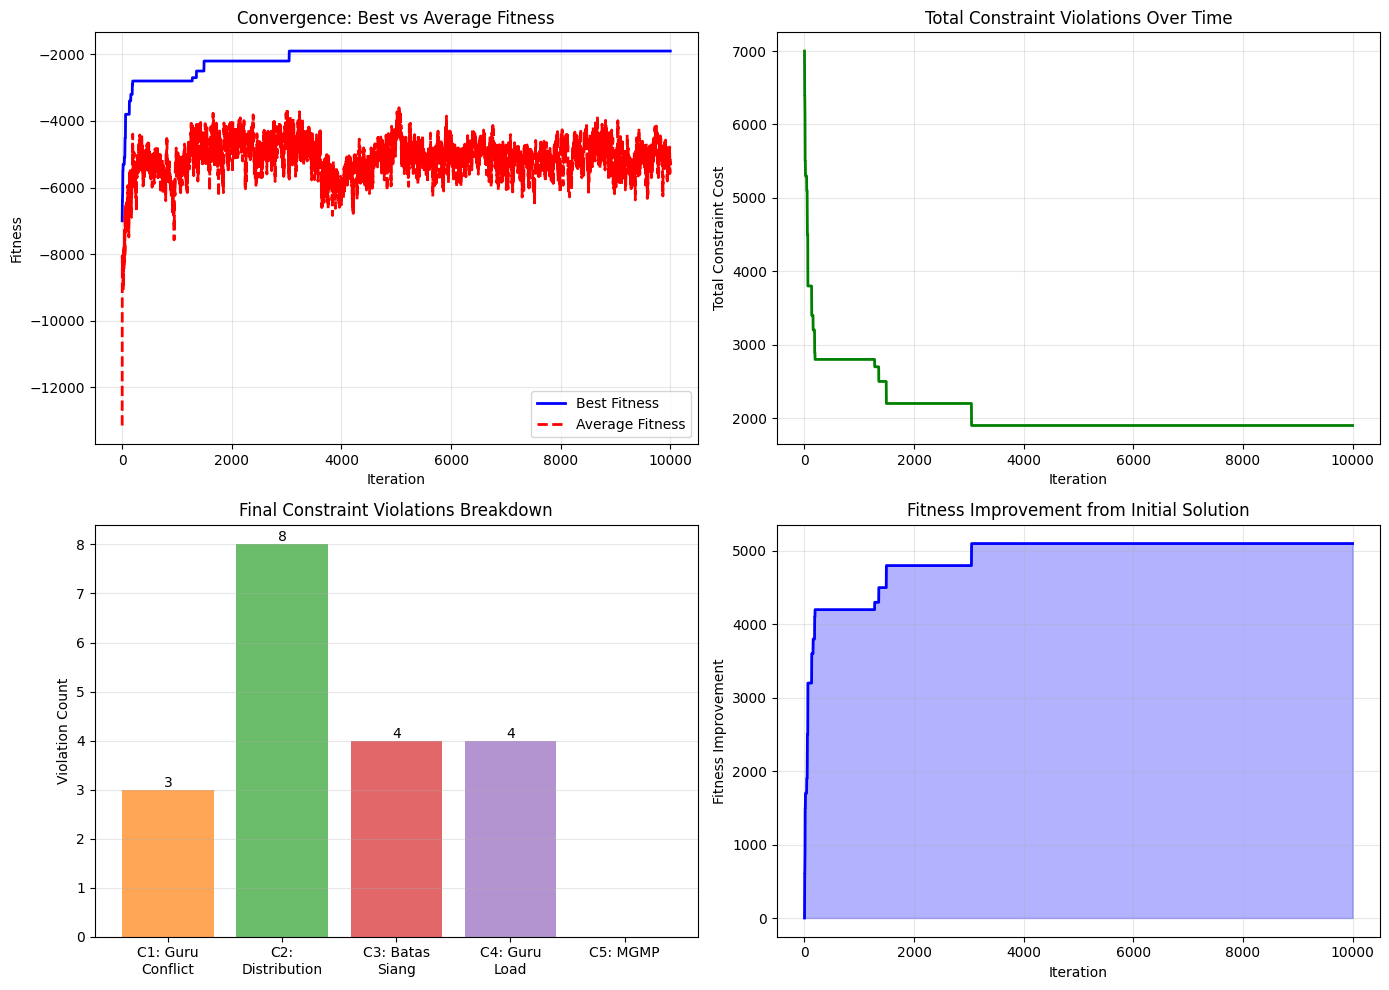

📊 Visualization created!


In [63]:
import matplotlib.pyplot as plt

# Plot convergence
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Best Fitness vs Average Fitness
ax1 = axes[0, 0]
ax1.plot(history['best_fitness'], 'b-', label='Best Fitness', linewidth=2)
ax1.plot(history['avg_fitness'], 'r--', label='Average Fitness', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Fitness')
ax1.set_title('Convergence: Best vs Average Fitness')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Total Cost Over Time
ax2 = axes[0, 1]
ax2.plot(history['constraints_violated'], 'g-', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Total Constraint Cost')
ax2.set_title('Total Constraint Violations Over Time')
ax2.grid(True, alpha=0.3)

# 3. Final Constraint Breakdown
ax3 = axes[1, 0]
constraints = ['C1: Guru\nConflict', 'C2:\nDistribution', 'C3: Batas\nSiang', 'C4: Guru\nLoad', 'C5: MGMP', 'C6:\nSlot Length']
violations = [
    best_fitness['c1_guru_conflict'],
    best_fitness['c2_distribution'],
    best_fitness['c3_batas_siang'],
    best_fitness['c4_guru_load'],
    best_fitness['c5_mgmp'],
    best_fitness.get('c6_slot_length',0)
]
colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = ax3.bar(constraints, violations, color=colors, alpha=0.7)
ax3.set_ylabel('Violation Count')
ax3.set_title('Final Constraint Violations Breakdown')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')

# 4. Fitness Improvement
ax4 = axes[1, 1]
initial_fitness = history['best_fitness'][0]
improvements = [(f - initial_fitness) for f in history['best_fitness']]
ax4.fill_between(range(len(improvements)), improvements, alpha=0.3, color='blue')
ax4.plot(improvements, 'b-', linewidth=2)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Fitness Improvement')
ax4.set_title('Fitness Improvement from Initial Solution')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Visualization created!")


In [75]:
# =========================================================
# DISPLAY HASIL JADWAL TERBAIK
# =========================================================

hari_names = {1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat'}

# helper to present a class schedule as a DataFrame

def schedule_to_dataframe(individual):
    """Convert an individual (single class schedule) into a pandas DataFrame.

    Rows are weekdays and columns are slot numbers. Empty slots shown as blank.
    """
    # use official slot counts per day rather than data content
    max_slots = max(slotPerHari.values()) if slotPerHari else 0
    data = {}
    for day in range(1, 6):
        slots = individual.get(day, [])
        row = []
        for i in range(max_slots):
            if i < len(slots):
                mid = slots[i]
                if mid > 0:
                    row.append(namaMapelDanId.get(mid, f"Mapel {mid}"))
                else:
                    row.append("")
            else:
                row.append("")
        data[day] = row
    df = pd.DataFrame.from_dict(data, orient='index',
                                  columns=[f"Slot {i+1}" for i in range(max_slots)])
    df.index = [hari_names[d] for d in df.index]
    return df


def display_schedule(individual, num_classes=27):
    """Show schedules for several classes using dataframes for readability."""
    print("\n" + "="*80)
    print("JADWAL TERBAIK (dalam bentuk tabel)")
    print("="*80)

    classes_to_show = liste_kelas[:num_classes]

    for kelas_id in classes_to_show:
        print(f"\n{'='*80}")
        print(f"KELAS {kelas_id} - {kelasDanTingkatan[kelas_id][0]['nama_kelas']}")
        print(f"{'='*80}")

        df = schedule_to_dataframe(individual[kelas_id])
        display(df)

        # show total distribution below table
        total_dist = {}
        for day in range(1, 6):
            for mapel_id in individual[kelas_id][day]:
                if mapel_id > 0:
                    total_dist[mapel_id] = total_dist.get(mapel_id, 0) + 1
        print("Total jam per mapel: ", end="")
        for mapel_id in sorted(total_dist.keys()):
            actual = total_dist[mapel_id]
            expected = jamPerMingguMapel[mapel_id]
            status = "✓" if actual == expected else "✗"
            print(f"{namaMapelDanId[mapel_id]}: {actual}/{expected} {status}; ", end="")
        print("\n")

# Display hasil
display_schedule(best_individual, num_classes=min(27, len(liste_kelas)))

# =========================================================
# CONSTRAINT ANALYSIS
# =========================================================

print("\n" + "="*80)
print("ANALISIS CONSTRAINT DETAIL")
print("="*80)

print(f"\n1️⃣  CONSTRAINT 1: Guru Conflict")
print(f"   Status: {best_fitness['c1_guru_conflict']} violations")
if best_fitness['c1_guru_conflict'] == 0:
    print(f"   ✓ TERPENUHI - Tidak ada guru yang mengajar 2 kelas bersamaan")
else:
    print(f"   ✗ BELUM TERPENUHI - Ada {best_fitness['c1_guru_conflict']} konflik guru")

print(f"\n2️⃣  CONSTRAINT 2: Distribution Jam Per Minggu")
print(f"   Status: {best_fitness['c2_distribution']} violations")
if best_fitness['c2_distribution'] == 0:
    print(f"   ✓ TERPENUHI - Semua mapel sesuai jam per minggu")
else:
    print(f"   ✗ BELUM TERPENUHI - {best_fitness['c2_distribution']} slot tidak sesuai")

print(f"\n3️⃣  CONSTRAINT 3: Batas Siang (Mapel 8)")
print(f"   Status: {best_fitness['c3_batas_siang']} violations")
if best_fitness['c3_batas_siang'] == 0:
    print(f"   ✓ TERPENUHI - Mapel 8 tidak melewati batas siang")
else:
    print(f"   ✗ BELUM TERPENUHI - Mapel 8 melewati batas siang {best_fitness['c3_batas_siang']} kali")

print(f"\n4️⃣  CONSTRAINT 4: Guru Load (Durasi Mengajar)")
print(f"   Status: {best_fitness['c4_guru_load']} violations")
if best_fitness['c4_guru_load'] == 0:
    print(f"   ✓ TERPENUHI - Semua guru sesuai durasi")
else:
    print(f"   ✗ BELUM TERPENUHI - {best_fitness['c4_guru_load']} jam melebihi durasi guru")

print(f"\n5️⃣  CONSTRAINT 5: MGMP Constraint")
print(f"   Status: {best_fitness['c5_mgmp']} violations")
if best_fitness['c5_mgmp'] == 0:
    print(f"   ✓ TERPENUHI - Mapel MGMP sesuai aturan")
else:
    print(f"   ✗ BELUM TERPENUHI - {best_fitness['c5_mgmp']} violation pada MGMP")

print(f"\n6️⃣  CONSTRAINT 6: Slot Length")
print(f"   Status: {best_fitness.get('c6_slot_length',0)} violations")
if best_fitness.get('c6_slot_length',0) == 0:
    print(f"   ✓ TERPENUHI - Semua hari panjang slot sesuai")
else:
    print(f"   ✗ BELUM TERPENUHI - {best_fitness.get('c6_slot_length',0)} slot kelebihan/kurang")

print(f"\n" + "="*80)
print("="*80)
print(f"TOTAL VIOLATIONS: {int((best_fitness['c1_guru_conflict'] + best_fitness['c2_distribution'] + best_fitness['c3_batas_siang'] + best_fitness['c4_guru_load'] + best_fitness['c5_mgmp'] + best_fitness.get('c6_slot_length',0)))}")


JADWAL TERBAIK (dalam bentuk tabel)

KELAS 1 - 7A


,Slot 1,Slot 2,Slot 3,Slot 4,Slot 5,Slot 6,Slot 7,Slot 8
Senin,PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI,ILMU PENGETAHUAN ALAM,BAHASA INDONESIA,BAHASA INDONESIA,PENDIDIKAN PANCASILA,PENDIDIKAN PANCASILA,MATEMATIKA,SENI
Selasa,PJOK,BAHASA INDONESIA,MATEMATIKA,,,,,
Rabu,MATEMATIKA,BAHASA INGGRIS,BAHASA INGGRIS,BAHASA INGGRIS,PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI,ILMU PENGETAHUAN ALAM,ILMU PENGETAHUAN ALAM,ILMU PENGETAHUAN ALAM
Kamis,MULOK,,,,,,,
Jumat,SENI,ILMU PENGETAHUAN SOSIAL,ILMU PENGETAHUAN SOSIAL,ILMU PENGETAHUAN SOSIAL,DINIYAH,BAHASA JAWA,MULOK,MULOK


Total jam per mapel: PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI: 2/2 ✓; PENDIDIKAN PANCASILA: 2/2 ✓; BAHASA INDONESIA: 5/5 ✓; MATEMATIKA: 3/4 ✗; ILMU PENGETAHUAN ALAM: 4/4 ✓; ILMU PENGETAHUAN SOSIAL: 3/3 ✓; BAHASA INGGRIS: 3/3 ✓; PJOK: 2/2 ✓; INFORMATIKA: 2/2 ✓; SENI: 2/2 ✓; BAHASA JAWA: 2/2 ✓; MULOK: 3/3 ✓; DINIYAH: 2/2 ✓; 


KELAS 2 - 7B


,Slot 1,Slot 2,Slot 3,Slot 4,Slot 5,Slot 6,Slot 7,Slot 8
Senin,ILMU PENGETAHUAN ALAM,ILMU PENGETAHUAN ALAM,ILMU PENGETAHUAN ALAM,INFORMATIKA,BAHASA INDONESIA,,,
Selasa,MATEMATIKA,INFORMATIKA,PENDIDIKAN PANCASILA,ILMU PENGETAHUAN ALAM,,,,
Rabu,ILMU PENGETAHUAN SOSIAL,ILMU PENGETAHUAN SOSIAL,PJOK,MULOK,,,,
Kamis,BAHASA INGGRIS,BAHASA INGGRIS,BAHASA INGGRIS,ILMU PENGETAHUAN ALAM,DINIYAH,DINIYAH,BAHASA INDONESIA,BAHASA INDONESIA
Jumat,PJOK,BAHASA INDONESIA,ILMU PENGETAHUAN SOSIAL,,,,,


Total jam per mapel: PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI: 2/2 ✓; PENDIDIKAN PANCASILA: 2/2 ✓; BAHASA INDONESIA: 5/5 ✓; MATEMATIKA: 4/4 ✓; ILMU PENGETAHUAN ALAM: 5/4 ✗; ILMU PENGETAHUAN SOSIAL: 3/3 ✓; BAHASA INGGRIS: 3/3 ✓; PJOK: 2/2 ✓; INFORMATIKA: 2/2 ✓; SENI: 2/2 ✓; BAHASA JAWA: 2/2 ✓; MULOK: 3/3 ✓; DINIYAH: 2/2 ✓; 


KELAS 3 - 7C


...

Total jam per mapel: PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI: 1/2 ✗; PENDIDIKAN PANCASILA: 2/2 ✓; BAHASA INDONESIA: 5/5 ✓; MATEMATIKA: 4/4 ✓; ILMU PENGETAHUAN ALAM: 4/4 ✓; ILMU PENGETAHUAN SOSIAL: 3/3 ✓; BAHASA INGGRIS: 3/3 ✓; PJOK: 2/2 ✓; INFORMATIKA: 2/2 ✓; SENI: 2/2 ✓; BAHASA JAWA: 2/2 ✓; MULOK: 3/3 ✓; DINIYAH: 2/2 ✓; 


KELAS 26 - 9H


,Slot 1,Slot 2,Slot 3,Slot 4,Slot 5,Slot 6,Slot 7,Slot 8
Senin,ILMU PENGETAHUAN ALAM,BAHASA INGGRIS,MULOK,MULOK,,,,
Selasa,ILMU PENGETAHUAN SOSIAL,BAHASA JAWA,INFORMATIKA,MATEMATIKA,,,,
Rabu,PJOK,PJOK,SENI,SENI,BAHASA JAWA,DINIYAH,DINIYAH,ILMU PENGETAHUAN SOSIAL
Kamis,PENDIDIKAN PANCASILA,BAHASA INGGRIS,BAHASA INGGRIS,BAHASA INDONESIA,MATEMATIKA,MATEMATIKA,MATEMATIKA,
Jumat,MULOK,BAHASA INDONESIA,BAHASA INDONESIA,ILMU PENGETAHUAN ALAM,PENDIDIKAN PANCASILA,PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI,PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI,


Total jam per mapel: PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI: 2/2 ✓; PENDIDIKAN PANCASILA: 2/2 ✓; BAHASA INDONESIA: 5/5 ✓; MATEMATIKA: 4/4 ✓; ILMU PENGETAHUAN ALAM: 4/4 ✓; ILMU PENGETAHUAN SOSIAL: 3/3 ✓; BAHASA INGGRIS: 3/3 ✓; PJOK: 2/2 ✓; INFORMATIKA: 2/2 ✓; SENI: 2/2 ✓; BAHASA JAWA: 2/2 ✓; MULOK: 3/3 ✓; DINIYAH: 2/2 ✓; 


KELAS 27 - 9I


,Slot 1,Slot 2,Slot 3,Slot 4,Slot 5,Slot 6,Slot 7,Slot 8
Senin,SENI,INFORMATIKA,,,,,,
Selasa,BAHASA INDONESIA,BAHASA INDONESIA,BAHASA INDONESIA,PJOK,MATEMATIKA,DINIYAH,DINIYAH,PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI
Rabu,PJOK,MULOK,INFORMATIKA,,,,,
Kamis,BAHASA INDONESIA,BAHASA INGGRIS,,,,,,
Jumat,ILMU PENGETAHUAN SOSIAL,ILMU PENGETAHUAN SOSIAL,ILMU PENGETAHUAN SOSIAL,BAHASA INDONESIA,SENI,BAHASA JAWA,ILMU PENGETAHUAN ALAM,ILMU PENGETAHUAN ALAM


Total jam per mapel: PENDIDIKAN AGAMA ISLAM DAN BUDI PEKERTI: 2/2 ✓; PENDIDIKAN PANCASILA: 2/2 ✓; BAHASA INDONESIA: 5/5 ✓; MATEMATIKA: 4/4 ✓; ILMU PENGETAHUAN ALAM: 4/4 ✓; ILMU PENGETAHUAN SOSIAL: 3/3 ✓; BAHASA INGGRIS: 3/3 ✓; PJOK: 2/2 ✓; INFORMATIKA: 2/2 ✓; SENI: 2/2 ✓; BAHASA JAWA: 2/2 ✓; MULOK: 3/3 ✓; DINIYAH: 2/2 ✓; 


ANALISIS CONSTRAINT DETAIL

1️⃣  CONSTRAINT 1: Guru Conflict
   Status: 1 violations
   ✗ BELUM TERPENUHI - Ada 1 konflik guru

2️⃣  CONSTRAINT 2: Distribution Jam Per Minggu
   Status: 6 violations
   ✗ BELUM TERPENUHI - 6 slot tidak sesuai

3️⃣  CONSTRAINT 3: Batas Siang (Mapel 8)
   Status: 7 violations
   ✗ BELUM TERPENUHI - Mapel 8 melewati batas siang 7 kali

4️⃣  CONSTRAINT 4: Guru Load (Durasi Mengajar)
   Status: 4 violations
   ✗ BELUM TERPENUHI - 4 jam melebihi durasi guru

5️⃣  CONSTRAINT 5: MGMP Constraint
   Status: 0 violations
   ✓ TERPENUHI - Mapel MGMP sesuai aturan

6️⃣  CONSTRAINT 6: Slot Length
   Status: 0 violations
   ✓ TERPENUHI - Semua hari